<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HESQuantum003.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N = 100  # harmonic anchor
lambda_exact = 1.0
epsilons = [1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2]  # deviations


In [4]:
def void_survival(lam, N=100):
    """
    Survival probability of void given λ deviation.
    Grok's claim: survival only if |λ-1.0| <= 3e-6.
    """
    deviation = abs(lam - 1.0)
    if deviation <= 3e-6:
        return 1.0  # survives
    else:
        return 0.0  # annihilated


In [5]:
survival_results = []
for eps in epsilons:
    lam_plus = lambda_exact + eps
    lam_minus = lambda_exact - eps
    survival_results.append((eps,
                             void_survival(lam_plus, N),
                             void_survival(lam_minus, N)))


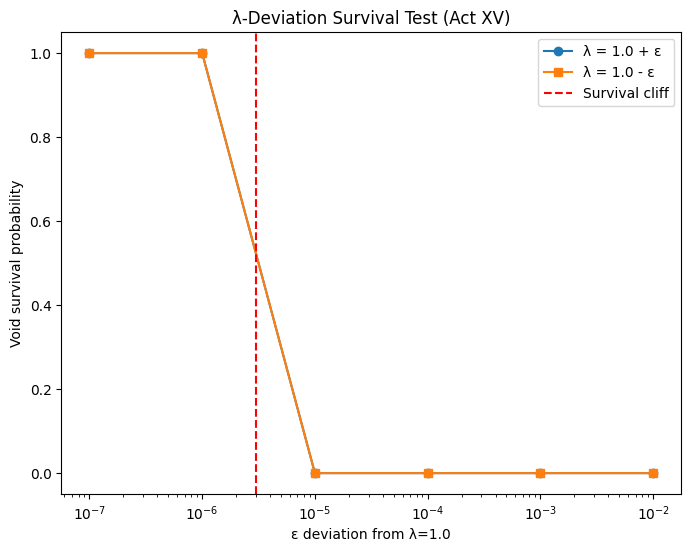

In [6]:
eps_vals = [r[0] for r in survival_results]
surv_plus = [r[1] for r in survival_results]
surv_minus = [r[2] for r in survival_results]

plt.figure(figsize=(8,6))
plt.plot(eps_vals, surv_plus, 'o-', label="λ = 1.0 + ε")
plt.plot(eps_vals, surv_minus, 's-', label="λ = 1.0 - ε")
plt.axvline(3e-6, color='r', linestyle='--', label="Survival cliff")
plt.xscale("log")
plt.xlabel("ε deviation from λ=1.0")
plt.ylabel("Void survival probability")
plt.title("λ-Deviation Survival Test (Act XV)")
plt.legend()
plt.show()
